# Model

## Genel Bakış

In [129]:
data = df14.copy()

In [130]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, r2_score, f1_score
import xgboost as xgb

def train_and_evaluate_models(df, target_column):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    models = {
        "Random Forest": RandomForestClassifier() if y.nunique() < 10 else RandomForestRegressor(),
        "Logistic Regression": LogisticRegression() if y.nunique() < 10 else None,
        "Artificial Neural Network": MLPClassifier() if y.nunique() < 10 else MLPRegressor(),
        "SVM": SVC() if y.nunique() < 10 else SVR(),
        "Gradient Boosting": GradientBoostingClassifier() if y.nunique() < 10 else GradientBoostingRegressor(),
        "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss') if y.nunique() < 10 else xgb.XGBRegressor(),
        "Decision Tree": DecisionTreeClassifier() if y.nunique() < 10 else DecisionTreeRegressor(),
        "KNN": KNeighborsClassifier() if y.nunique() < 10 else KNeighborsRegressor()
    }
    
    results = []
    
    for name, model in models.items():
        if model is None:
            continue
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
        
        if y.nunique() < 10:
            train_score = accuracy_score(y_train, y_train_pred)
            test_score = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
        else:
            train_score = r2_score(y_train, y_train_pred)
            test_score = r2_score(y_test, y_pred)
            f1 = None 
        
        results.append({
            "Model": name,
            "Train Score": train_score,
            "Test Score": test_score,
            "F1 Score": f1
        })
    
    results_df = pd.DataFrame(results)
    print(results_df)
    
    return results_df


In [131]:
train_and_evaluate_models(data,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9505  0.949450
1        Logistic Regression     0.805000      0.8105  0.766455
2  Artificial Neural Network     0.971125      0.9495  0.949126
3                        SVM     0.950625      0.9445  0.942548
4          Gradient Boosting     0.946500      0.9495  0.948372
5                    XGBoost     0.999750      0.9640  0.963566
6              Decision Tree     1.000000      0.9230  0.922776
7                        KNN     0.925375      0.8990  0.893439


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9505,0.949450
1,Logistic Regression,0.805000,0.8105,0.766455
2,Artificial Neural Network,0.971125,0.9495,0.949126
3,SVM,0.950625,0.9445,0.942548
4,Gradient Boosting,0.946500,0.9495,0.948372
5,XGBoost,0.999750,0.9640,0.963566
6,Decision Tree,1.000000,0.9230,0.922776
7,KNN,0.925375,0.8990,0.893439


In [132]:
data1 = data.copy()

In [133]:
data1 = data1.drop(columns=["Card_Type", "Point_Earned", "EstimatedSalary"])

In [134]:
data1 = data1.drop(columns=["Gender"])

In [135]:
train_and_evaluate_models(data1,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9570  0.956253
1        Logistic Regression     0.805000      0.8055  0.759206
2  Artificial Neural Network     0.966250      0.9560  0.955562
3                        SVM     0.952500      0.9510  0.949823
4          Gradient Boosting     0.946875      0.9480  0.946692
5                    XGBoost     0.997500      0.9665  0.966149
6              Decision Tree     1.000000      0.9220  0.922075
7                        KNN     0.947500      0.9275  0.925297


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9570,0.956253
1,Logistic Regression,0.805000,0.8055,0.759206
2,Artificial Neural Network,0.966250,0.9560,0.955562
3,SVM,0.952500,0.9510,0.949823
4,Gradient Boosting,0.946875,0.9480,0.946692
5,XGBoost,0.997500,0.9665,0.966149
6,Decision Tree,1.000000,0.9220,0.922075
7,KNN,0.947500,0.9275,0.925297


In [136]:
# data1 = data1.drop([ 'CreditScore', 'HasCrCard', 'Geography', 'Tenure'], axis=1)

## Gradient Boosting

In [137]:
data_1 = data1.copy()

In [138]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Özellikler ve hedef değişkeni ayır
X = data_1.drop("Exited", axis=1)
y = data_1["Exited"]

# Veriyi eğitim ve test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting modelini oluştur
gbm_1 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modeli eğit
gbm_1.fit(X_train, y_train)

# Tahmin yap
y_pred = gbm_1.predict(X_test)

# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")


Model Doğruluğu: 0.9480


In [139]:
# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")

# F1 skoru
f1 = f1_score(y_test, y_pred)
print(f"F1 Skoru: {f1:.4f}")

# Test seti boyutu
test_size = len(y_test)
print(f"Test Seti Boyutu: {test_size}")

Model Doğruluğu: 0.9480
F1 Skoru: 0.8591
Test Seti Boyutu: 2000


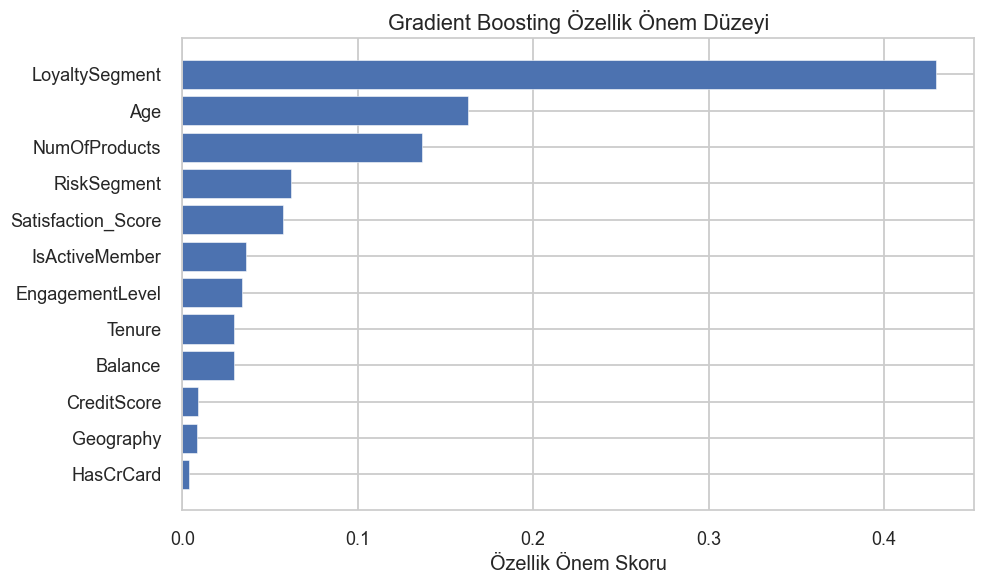

In [140]:
# Feature Importance (Özelliklerin Önemi)
feature_importance = gbm_1.feature_importances_
sorted_idx = np.argsort(feature_importance)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], feature_importance[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Gradient Boosting Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()

In [141]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1607
           1       0.92      0.81      0.86       393

    accuracy                           0.95      2000
   macro avg       0.94      0.89      0.91      2000
weighted avg       0.95      0.95      0.95      2000



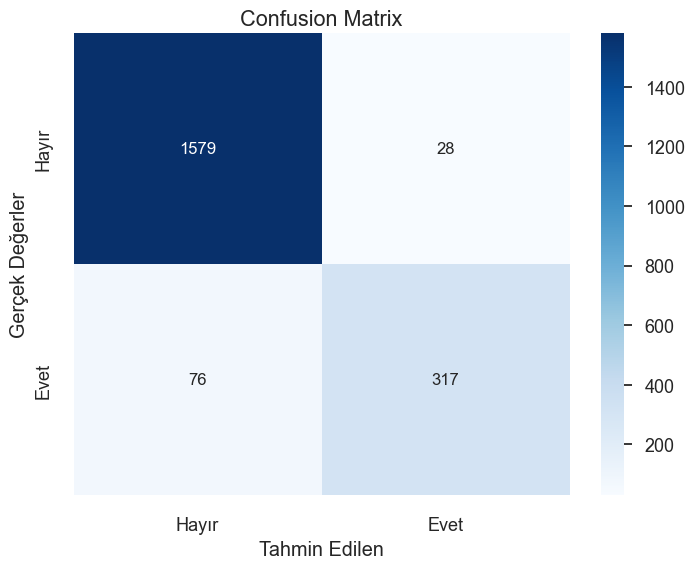

In [142]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


### simülasyon

#### Resampling

In [143]:
data_real = data_1.copy()

In [144]:
data_real.Exited.value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [145]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real = data_real[data_real['Exited'] == 1]
majority_class_real = data_real[data_real['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
balanced_data_real = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
balanced_data_real['Exited'].value_counts(), balanced_data_real.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [146]:
balanced_data_real.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15924 entries, 1 to 3935
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         15924 non-null  int64  
 1   Geography           15924 non-null  int32  
 2   Age                 15924 non-null  int64  
 3   Tenure              15924 non-null  int64  
 4   Balance             15924 non-null  float64
 5   NumOfProducts       15924 non-null  int64  
 6   HasCrCard           15924 non-null  int64  
 7   IsActiveMember      15924 non-null  int64  
 8   Exited              15924 non-null  int64  
 9   Satisfaction_Score  15924 non-null  int64  
 10  LoyaltySegment      15924 non-null  int32  
 11  EngagementLevel     15924 non-null  int32  
 12  RiskSegment         15924 non-null  int32  
dtypes: float64(1), int32(4), int64(8)
memory usage: 1.5 MB


In [147]:
balanced_data_real.Exited.value_counts()

Exited
0    7962
1    7962
Name: count, dtype: int64

In [148]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Özellikler ve hedef değişkeni ayır
X = balanced_data_real.drop("Exited", axis=1)
y = balanced_data_real["Exited"]

# Veriyi eğitim ve test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting modelini oluştur
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modeli eğit
gbm.fit(X_train, y_train)

# Tahmin yap
y_pred = gbm.predict(X_test)

# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")


Model Doğruluğu: 0.9334


In [149]:
# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")

# F1 skoru
f1 = f1_score(y_test, y_pred)
print(f"F1 Skoru: {f1:.4f}")

# Test seti boyutu
test_size = len(y_test)
print(f"Test Seti Boyutu: {test_size}")

Model Doğruluğu: 0.9334
F1 Skoru: 0.9326
Test Seti Boyutu: 3185


In [150]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1620
           1       0.93      0.94      0.93      1565

    accuracy                           0.93      3185
   macro avg       0.93      0.93      0.93      3185
weighted avg       0.93      0.93      0.93      3185



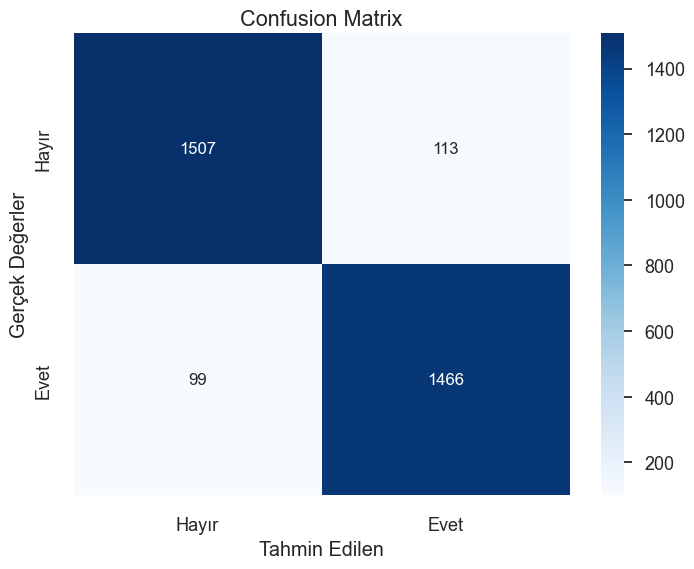

In [151]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


AUC: 0.9856


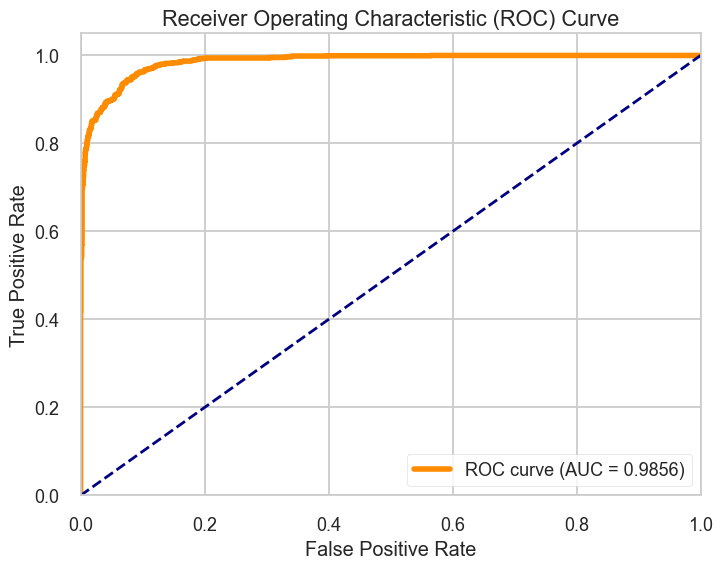

In [152]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Modelin tahmin ettiği sınıf olasılıkları (pozitif sınıf için)
y_prob = gbm.predict_proba(X_test)[:, 1]  # Pozitif sınıfın (Exited=1) olasılıkları

# ROC eğrisini hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC değerini hesapla
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=4, label=f'ROC curve (AUC = {roc_auc:.4f})')  # linewidth=4 ile kalınlaştırdık
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


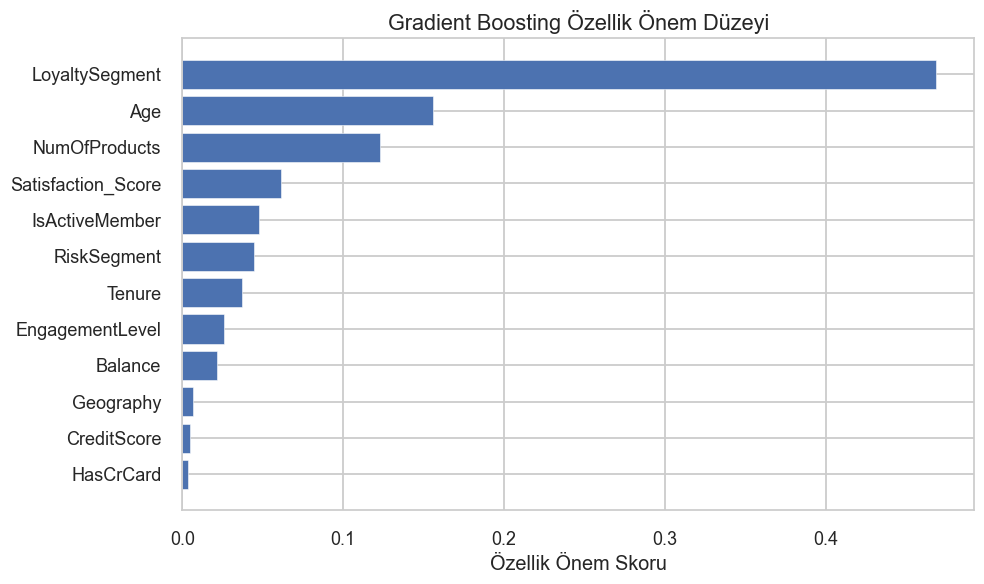

In [153]:
# Feature Importance (Özelliklerin Önemi)
feature_importance = gbm.feature_importances_
sorted_idx = np.argsort(feature_importance)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], feature_importance[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Gradient Boosting Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()

#### Undersampling

In [154]:
data_real_1 = data_1.copy()

In [155]:
data_real_1.Exited.value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [156]:
from sklearn.utils import resample
import pandas as pd

# Çoğunluk ve azınlık sınıfı ayır
majority = data_real_1[data_real_1["Exited"] == 0]
minority = data_real_1[data_real_1["Exited"] == 1]

# Çoğunluk sınıfı azınlık sınıfı kadar örnekle (rastgele)
majority_downsampled = resample(majority,
                                replace=False,       # tekrar seçmeden
                                n_samples=len(minority),  # azınlık kadar örnek
                                random_state=42)     # tekrarlanabilirlik için

# Yeni dengelenmiş veri setini oluştur
data_balanced = pd.concat([majority_downsampled, minority])

# Satırları karıştır
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [157]:
print(data_balanced["Exited"].value_counts())


Exited
0    2038
1    2038
Name: count, dtype: int64


In [158]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Özellikler ve hedef değişkeni ayır
X = data_balanced.drop("Exited", axis=1)
y = data_balanced["Exited"]

# Veriyi eğitim ve test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting modelini oluştur
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modeli eğit
gbm.fit(X_train, y_train)

# Tahmin yap
y_pred = gbm.predict(X_test)

In [159]:
# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")

# F1 skoru
f1 = f1_score(y_test, y_pred)
print(f"F1 Skoru: {f1:.4f}")

# Test seti boyutu
test_size = len(y_test)
print(f"Test Seti Boyutu: {test_size}")

Model Doğruluğu: 0.9130
F1 Skoru: 0.9125
Test Seti Boyutu: 816


In [160]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       416
           1       0.90      0.93      0.91       400

    accuracy                           0.91       816
   macro avg       0.91      0.91      0.91       816
weighted avg       0.91      0.91      0.91       816



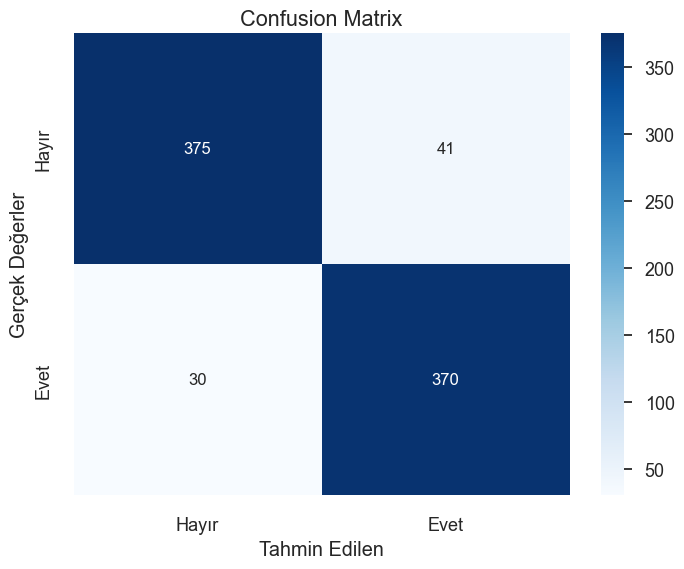

In [161]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


AUC: 0.9736


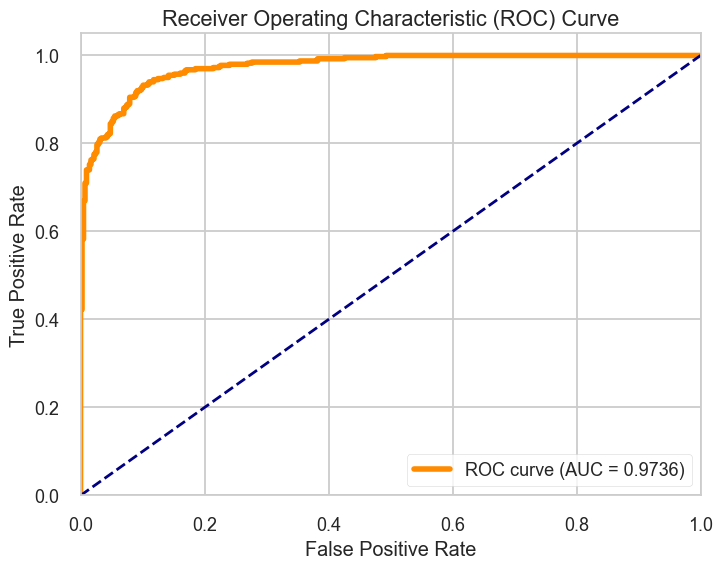

In [162]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Modelin tahmin ettiği sınıf olasılıkları (pozitif sınıf için)
y_prob = gbm.predict_proba(X_test)[:, 1]  # Pozitif sınıfın (Exited=1) olasılıkları

# ROC eğrisini hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC değerini hesapla
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=4, label=f'ROC curve (AUC = {roc_auc:.4f})')  # linewidth=4 ile kalınlaştırdık
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


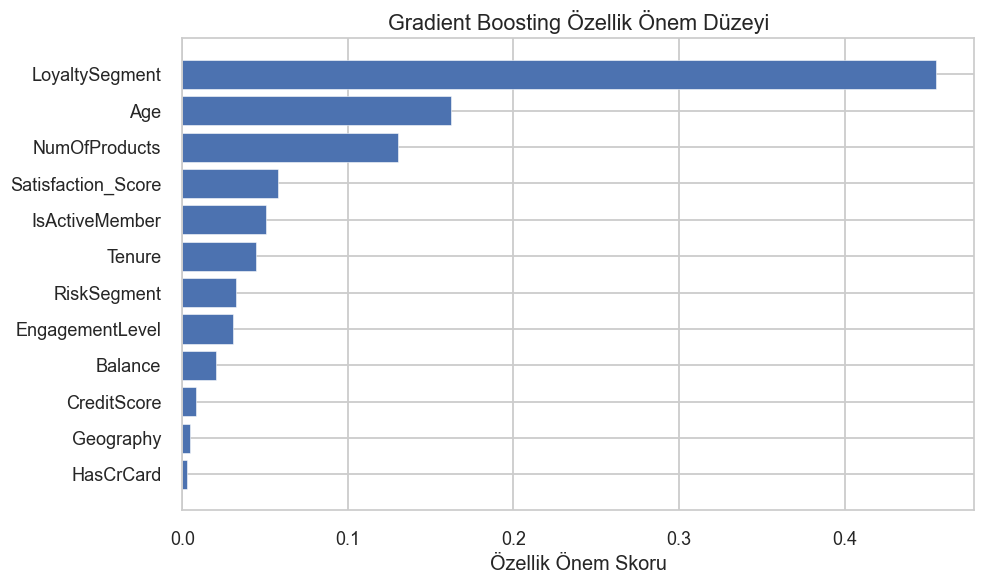

In [163]:
# Feature Importance (Özelliklerin Önemi)
feature_importance = gbm.feature_importances_
sorted_idx = np.argsort(feature_importance)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], feature_importance[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Gradient Boosting Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()

## Artificial Neural Network

In [164]:
data_2 = data1.copy()

In [165]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Özellikler ve hedef değişkeni ayır
X = data_2.drop("Exited", axis=1)
y = data_2["Exited"]

# Veriyi eğitim ve test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Veriyi ölçeklendir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeli oluştur
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification için sigmoid

# Modeli derle
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Modeli eğit
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Modeli test et
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


C:\Users\mehdi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7551 - loss: 0.5427 - val_accuracy: 0.8006 - val_loss: 0.3953
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8163 - loss: 0.3744 - val_accuracy: 0.8625 - val_loss: 0.3020
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8764 - loss: 0.2839 - val_accuracy: 0.9144 - val_loss: 0.2302
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9210 - loss: 0.2219 - val_accuracy: 0.9256 - val_loss: 0.1917
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9331 - loss: 0.1898 - val_accuracy: 0.9337 - val_loss: 0.1762
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9333 - loss: 0.1744 - val_accuracy: 0.9356 - val_loss: 0.1674
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9359 - loss: 0.1632 - val_accuracy: 0.9369 - val_loss: 0.1637
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9411 - loss: 0.1593 - val_accuracy: 0.

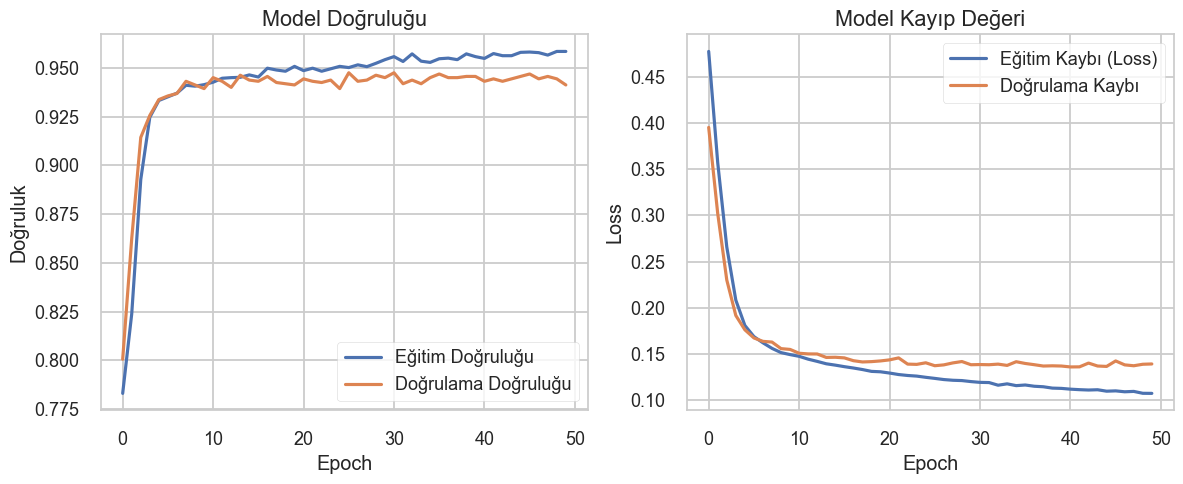

In [166]:
import matplotlib.pyplot as plt

# Accuracy grafiği
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Model Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# Loss grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kayıp Değeri')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Logistic Regression

In [167]:
df_log = data1.copy()

In [168]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Özellikler ve hedef değişkeni ayır
X = df_log.drop("Exited", axis=1)
y = df_log["Exited"]

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluştur
log_model_2 = LogisticRegression(max_iter=1000, random_state=42)

# Modeli eğit
log_model_2.fit(X_train, y_train)

# Tahmin yap
y_pred = log_model_2.predict(X_test)

In [169]:
# Skorları hesapla
train_score = log_model_2.score(X_train, y_train)
test_score = log_model_2.score(X_test, y_test)
f1 = f1_score(y_test, y_pred)

# Sonuçları tablo halinde göster
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Train Score": [train_score],
    "Test Score": [test_score],
    "F1 Score": [f1]
})

print(results)

                 Model  Train Score  Test Score  F1 Score
0  Logistic Regression     0.787875       0.798  0.117904


In [170]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      1607
           1       0.42      0.07      0.12       393

    accuracy                           0.80      2000
   macro avg       0.61      0.52      0.50      2000
weighted avg       0.73      0.80      0.74      2000



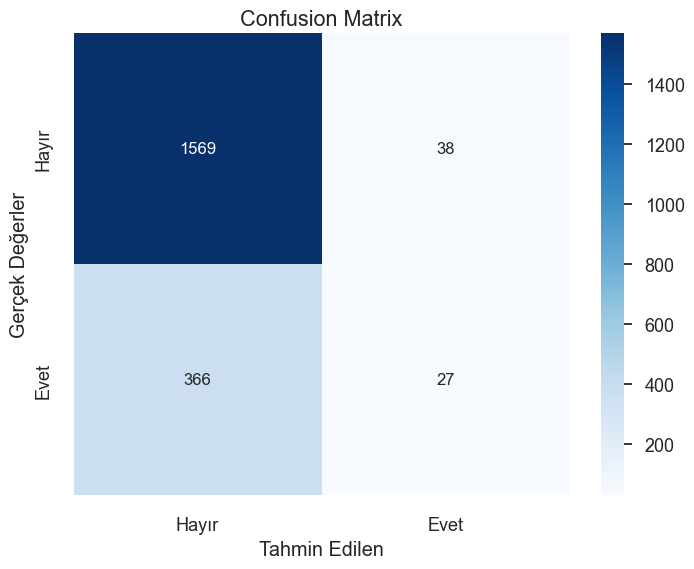

In [171]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


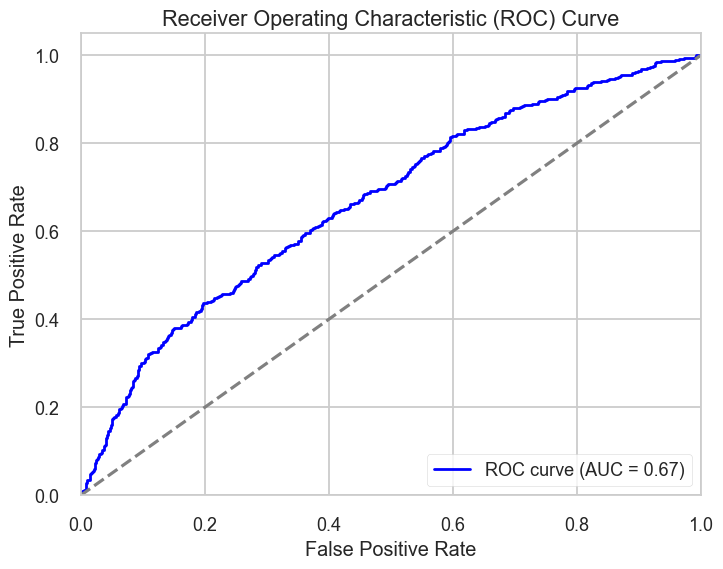

In [172]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True Positive Rate (TPR) ve False Positive Rate (FPR) hesapla
fpr, tpr, thresholds = roc_curve(y_test, log_model_2.predict_proba(X_test)[:, 1])

# AUC (Area Under the Curve) hesapla
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

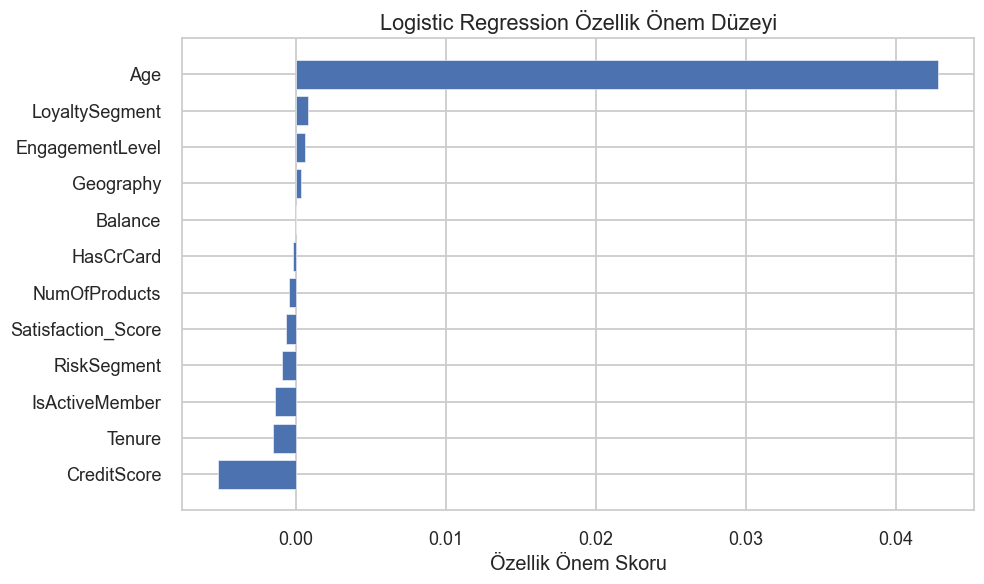

In [173]:
# Logistic Regression modelinden katsayıları al
coefficients = log_model_2.coef_[0]

# Özellik isimlerini al
sorted_idx = np.argsort(coefficients)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], coefficients[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Logistic Regression Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()


### simülasyon

#### Resampling

In [174]:
data_real_2 = data1.copy()

In [175]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real = data_real_2[data_real_2['Exited'] == 1]
majority_class_real = data_real_2[data_real_2['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
balanced_data_real = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
balanced_data_real['Exited'].value_counts(), balanced_data_real.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Özellikler ve hedef değişkeni ayır
X = balanced_data_real.drop("Exited", axis=1)
y = balanced_data_real["Exited"]

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluştur
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Modeli eğit
log_model.fit(X_train, y_train)

# Tahmin yap
y_pred = log_model.predict(X_test)

In [177]:
# Skorları hesapla
train_score = log_model.score(X_train, y_train)
test_score = log_model.score(X_test, y_test)
f1 = f1_score(y_test, y_pred)

# Sonuçları tablo halinde göster
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Train Score": [train_score],
    "Test Score": [test_score],
    "F1 Score": [f1]
})

print(results)

                 Model  Train Score  Test Score  F1 Score
0  Logistic Regression     0.657744    0.671272  0.669403


In [178]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.68      0.67      0.67      1620
           1       0.66      0.68      0.67      1565

    accuracy                           0.67      3185
   macro avg       0.67      0.67      0.67      3185
weighted avg       0.67      0.67      0.67      3185



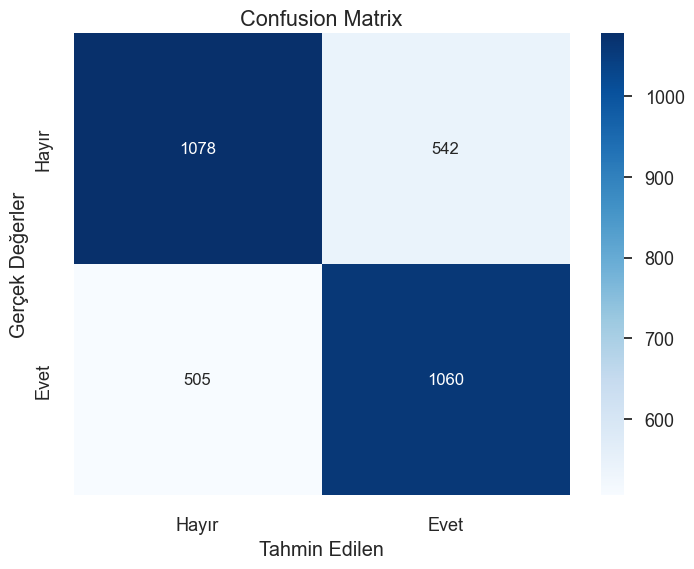

In [179]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


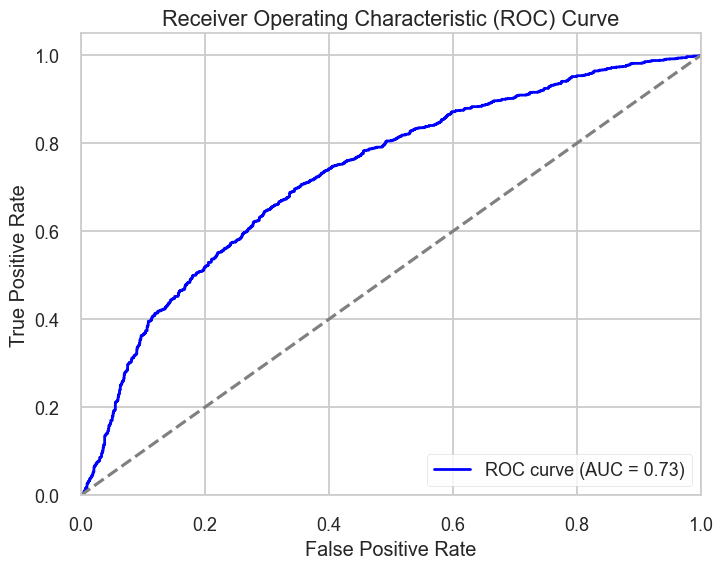

In [180]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True Positive Rate (TPR) ve False Positive Rate (FPR) hesapla
fpr, tpr, thresholds = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])

# AUC (Area Under the Curve) hesapla
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

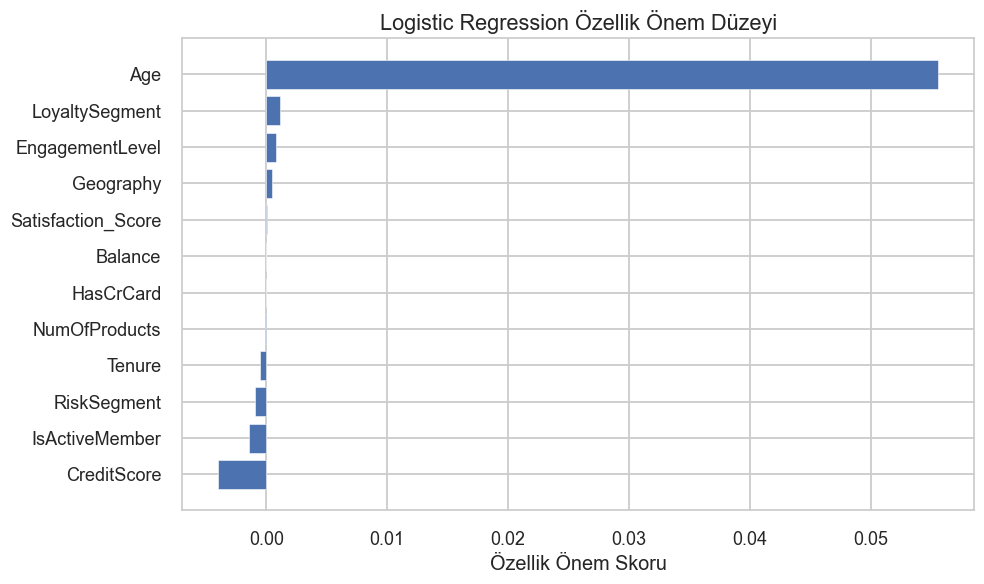

In [181]:
# Logistic Regression modelinden katsayıları al
coefficients = log_model.coef_[0]

# Özellik isimlerini al
sorted_idx = np.argsort(coefficients)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], coefficients[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Logistic Regression Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()


##### Parametre Optimizasyonu (GridSearchCV ile)

In [182]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# Özellikler ve hedef değişkeni ayır
X = balanced_data_real.drop("Exited", axis=1)
y = balanced_data_real["Exited"]

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression modelini oluştur
log_model = LogisticRegression(max_iter=1000, random_state=42)

In [183]:
# Parametreler için bir grid tanımla
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularizasyon gücü
    'penalty': ['l1', 'l2'],  # Regularizasyon türü
    'solver': ['liblinear', 'saga'],  # Çözümleyici türü
}

In [184]:
# GridSearchCV ile parametre optimizasyonu yap
grid_search = GridSearchCV(estimator=log_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1', verbose=1)

In [185]:
# En iyi parametreleri al
best_params = grid_search.best_params_
print(f"En iyi parametreler: {best_params}")

En iyi parametreler: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [186]:
# En iyi modeli al
best_log_model = grid_search.best_estimator_

In [187]:
# Test setinde tahmin yap
y_pred = best_log_model.predict(X_test)

# Modelin başarı oranlarını yazdır
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [188]:
print(f"En İyi Model Test Doğruluğu: {accuracy:.4f}")
print(f"En İyi Model F1 Skoru: {f1:.4f}")

En İyi Model Test Doğruluğu: 0.7061
En İyi Model F1 Skoru: 0.7019


#### Undersampling

In [189]:
data_real_ = data1.copy()

In [190]:
from sklearn.utils import resample
import pandas as pd

# Çoğunluk ve azınlık sınıfı ayır
majority = data_real_[data_real_["Exited"] == 0]
minority = data_real_[data_real_["Exited"] == 1]

# Çoğunluk sınıfı azınlık sınıfı kadar örnekle (rastgele)
majority_downsampled = resample(majority,
                                replace=False,       # tekrar seçmeden
                                n_samples=len(minority),  # azınlık kadar örnek
                                random_state=42)     # tekrarlanabilirlik için

# Yeni dengelenmiş veri setini oluştur
data_balanced = pd.concat([majority_downsampled, minority])

# Satırları karıştır
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [191]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Özellikler ve hedef değişkeni ayır
X = data_balanced.drop("Exited", axis=1)
y = data_balanced["Exited"]

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluştur
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Modeli eğit
log_model.fit(X_train, y_train)

# Tahmin yap
y_pred = log_model.predict(X_test)

In [192]:
# Skorları hesapla
train_score = log_model.score(X_train, y_train)
test_score = log_model.score(X_test, y_test)
f1 = f1_score(y_test, y_pred)

# Sonuçları tablo halinde göster
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Train Score": [train_score],
    "Test Score": [test_score],
    "F1 Score": [f1]
})

print(results)

                 Model  Train Score  Test Score  F1 Score
0  Logistic Regression     0.658589    0.667892  0.669109


In [193]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.68      0.65      0.67       416
           1       0.65      0.69      0.67       400

    accuracy                           0.67       816
   macro avg       0.67      0.67      0.67       816
weighted avg       0.67      0.67      0.67       816



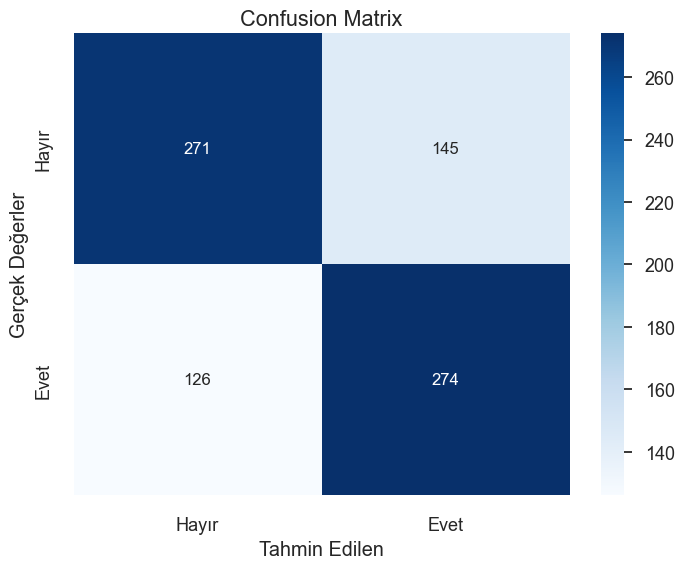

In [194]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


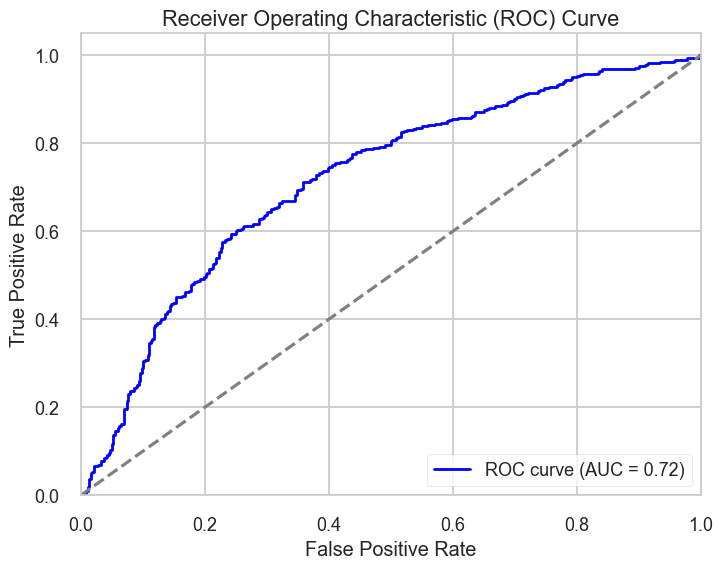

In [195]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True Positive Rate (TPR) ve False Positive Rate (FPR) hesapla
fpr, tpr, thresholds = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])

# AUC (Area Under the Curve) hesapla
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

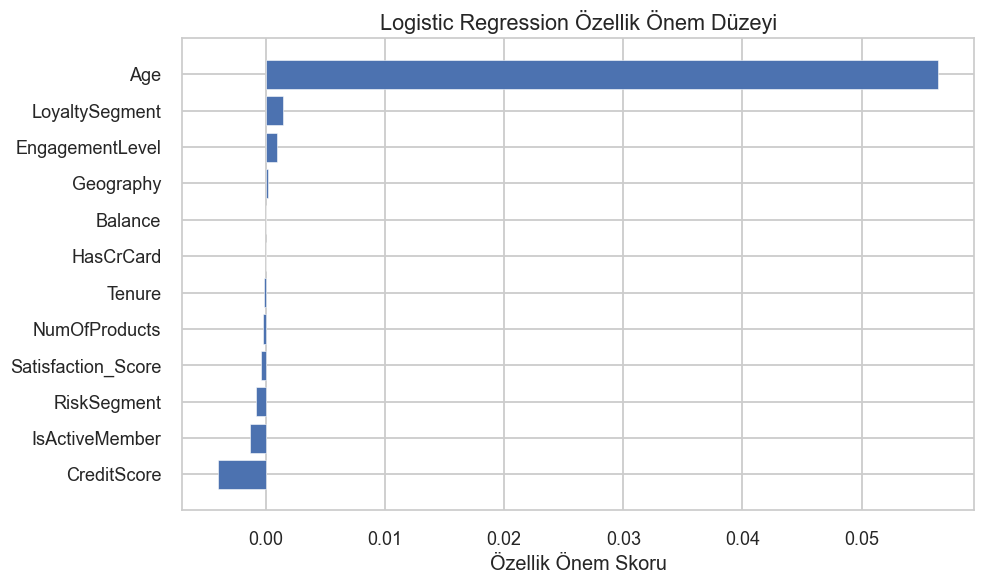

In [196]:
# Logistic Regression modelinden katsayıları al
coefficients = log_model.coef_[0]

# Özellik isimlerini al
sorted_idx = np.argsort(coefficients)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], coefficients[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Logistic Regression Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()


## SVM

In [197]:
df_svm = data1.copy()

In [198]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

In [199]:
X = df_svm.drop('Exited', axis=1)
y = df_svm['Exited']

In [200]:
# Verinin ölçeklenmesi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [202]:
svm_model_3 = SVC(kernel='rbf', random_state=42)
svm_model_3.fit(X_train, y_train)

SVC(random_state=42)

In [203]:
# Tahmin ve başarı ölçümleri
y_pred = svm_model_3.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9510
F1 Score: 0.8676


### Optimizasyon

In [204]:
svm_params= {"C":np.arange(1,5),
            "kernel":["linear","rbf"]}

In [205]:
svm= SVC()

In [206]:
svm_cv_model= GridSearchCV(svm,svm_params,cv=5,n_jobs=-1,verbose=2).fit(X_train,y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [207]:
svm_cv_model.best_score_

0.9456249999999999

In [208]:
#Hiperparametre
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}


In [209]:
#GridSearchCV
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             scoring='f1', verbose=1)

In [210]:
# best model
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)


In [211]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("En iyi parametreler:", grid.best_params_)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

En iyi parametreler: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.9505
F1 Score: 0.8692


In [212]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sınıflandırma raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1607
           1       0.90      0.84      0.87       393

    accuracy                           0.95      2000
   macro avg       0.93      0.91      0.92      2000
weighted avg       0.95      0.95      0.95      2000



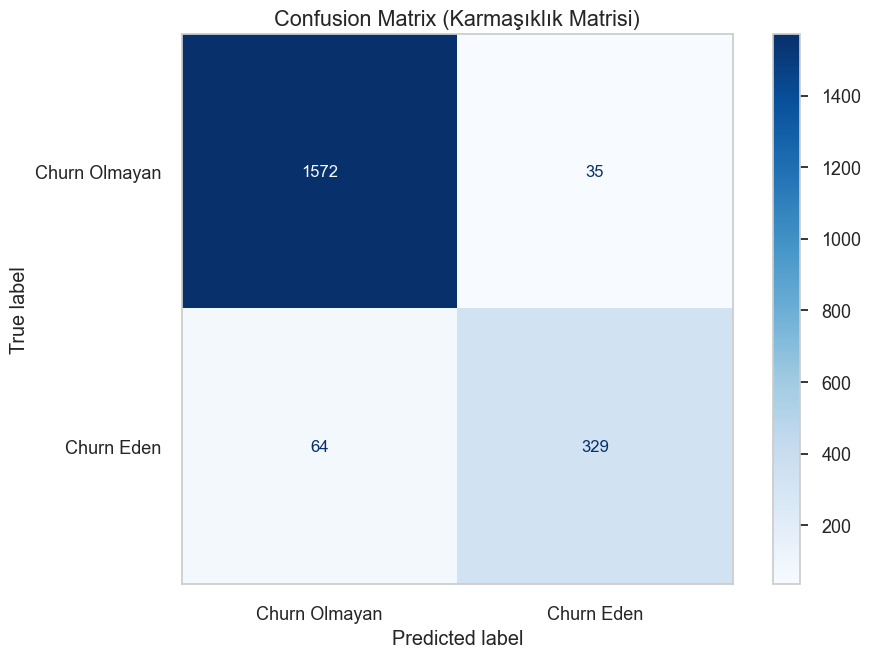

In [213]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Churn Olmayan", "Churn Eden"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Karmaşıklık Matrisi)")
plt.grid(False)
plt.show()

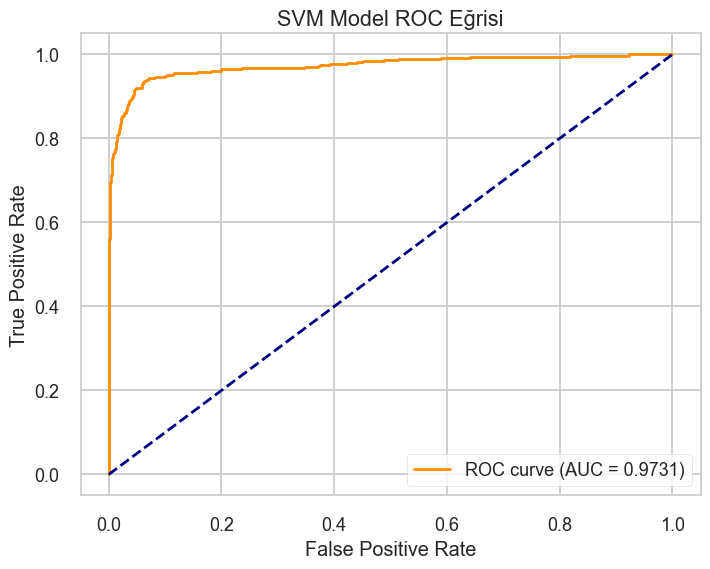

In [214]:
best_svm = SVC(kernel='rbf', C=grid.best_params_['C'], gamma=grid.best_params_['gamma'], probability=True)
best_svm.fit(X_train, y_train)

# Test seti için olasılık tahminleri
y_proba = best_svm.predict_proba(X_test)[:, 1]

# ROC eğrisi için false positive rate, true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM Model ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### similasyon

In [215]:
df_svm_res = df_svm.copy()

In [216]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real = df_svm_res[df_svm_res['Exited'] == 1]
majority_class_real = df_svm_res[df_svm_res['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
balanced_data_real = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
balanced_data_real['Exited'].value_counts(), balanced_data_real.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [217]:
X = balanced_data_real.drop('Exited', axis=1)
y = balanced_data_real['Exited']

# Verinin ölçeklenmesi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Eğitim ve test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)


y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9422
F1 Score: 0.9418


In [218]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sınıflandırma raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1620
           1       0.93      0.95      0.94      1565

    accuracy                           0.94      3185
   macro avg       0.94      0.94      0.94      3185
weighted avg       0.94      0.94      0.94      3185



In [219]:
#Hiperparametre
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}


In [220]:
#GridSearchCV
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             scoring='f1', verbose=1)

In [221]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("En iyi parametreler:", grid.best_params_)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

En iyi parametreler: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Accuracy: 0.9422
F1 Score: 0.9418


In [222]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sınıflandırma raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1620
           1       0.93      0.95      0.94      1565

    accuracy                           0.94      3185
   macro avg       0.94      0.94      0.94      3185
weighted avg       0.94      0.94      0.94      3185



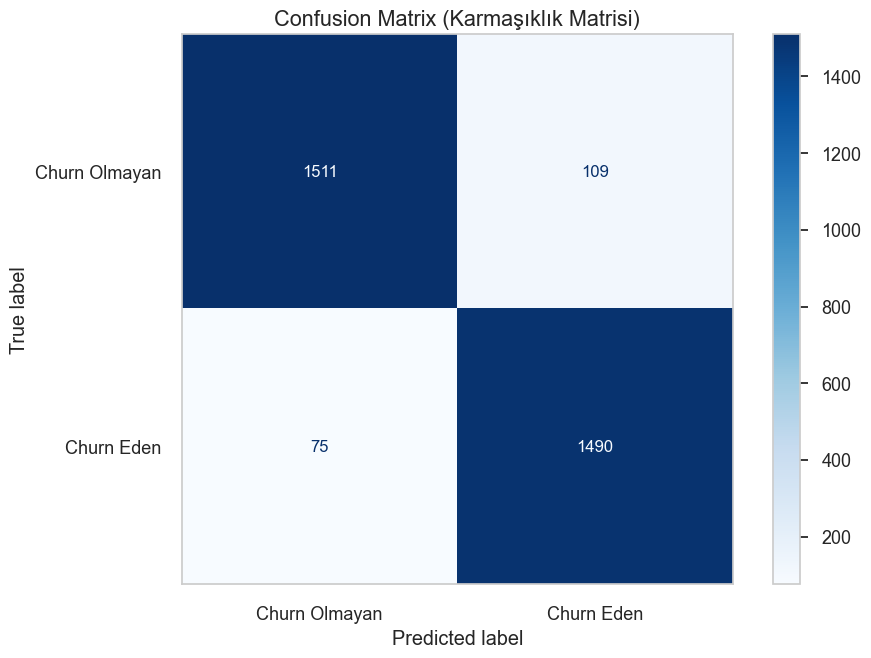

In [223]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Churn Olmayan", "Churn Eden"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Karmaşıklık Matrisi)")
plt.grid(False)
plt.show()

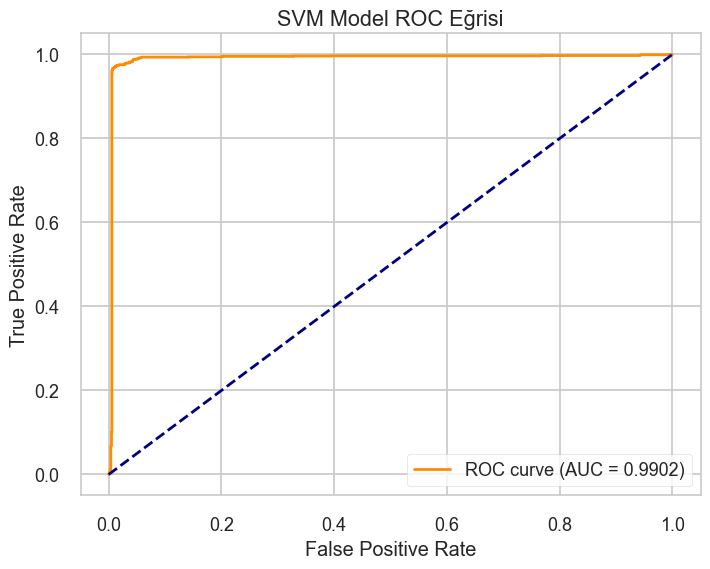

In [224]:
best_svm = SVC(kernel='rbf', C=grid.best_params_['C'], gamma=grid.best_params_['gamma'], probability=True)
best_svm.fit(X_train, y_train)

# Test seti için olasılık tahminleri
y_proba = best_svm.predict_proba(X_test)[:, 1]

# ROC eğrisi için false positive rate, true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM Model ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## KNN

In [225]:
df_knn = data1.copy()

In [226]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

In [227]:
X = df_knn.drop('Exited', axis=1)
y = df_knn['Exited']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [228]:
knn_model_4 = KNeighborsClassifier(n_neighbors=5)  # n_neighbors parametresi varsayılan olarak 5
knn_model_4.fit(X_train, y_train)

# Tahmin ve başarı ölçümleri
y_pred = knn_model_4.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9275
F1 Score: 0.8011


#### Optimizasyon 

In [229]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}


In [230]:
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# En iyi parametreleri ve modeli al
best_knn_model = grid_search.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [231]:
y_pred_best = best_knn_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Best KNN Accuracy: {accuracy_best:.4f}")
print(f"Best KNN F1 Score: {f1_best:.4f}")
print(f"Best K: {grid_search.best_params_['n_neighbors']}")

Best KNN Accuracy: 0.9300
Best KNN F1 Score: 0.8118
Best K: 3


In [232]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sınıflandırma raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1607
           1       0.87      0.74      0.80       393

    accuracy                           0.93      2000
   macro avg       0.90      0.86      0.88      2000
weighted avg       0.93      0.93      0.93      2000



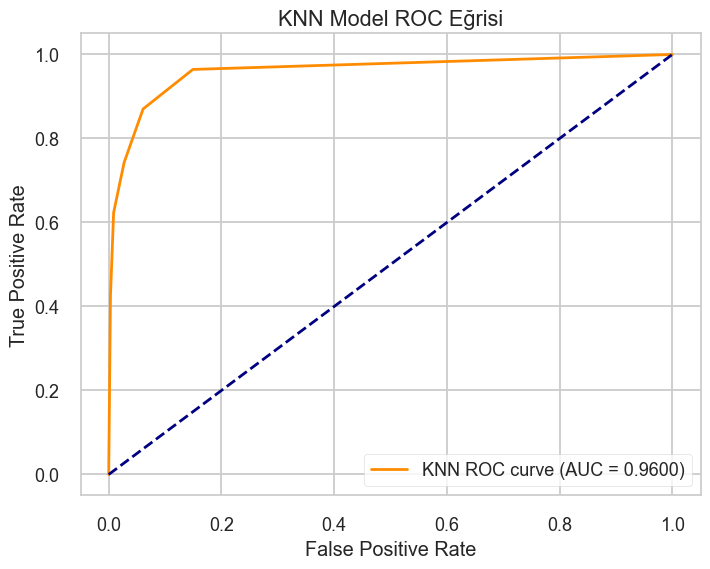

In [233]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# KNN modelini kullanarak olasılık tahminleri (class 1 için)
y_proba_knn = knn_model_4.predict_proba(X_test)[:, 1]

# ROC eğrisini hesapla
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label=f'KNN ROC curve (AUC = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN Model ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## CatBoost

In [234]:
df_cat = data1.copy()

In [235]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Özellikler ve hedef değişken
X = df_cat.drop("Exited", axis=1)
y = df_cat["Exited"]

# 2. Eğitim ve test bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Kategorik sütun indekslerini al 
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

# 4. Modeli tanımla ve eğit
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

# 5. Tahmin ve değerlendirme
y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9680


In [236]:
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9734    0.9868    0.9800      1592
           1     0.9456    0.8946    0.9194       408

    accuracy                         0.9680      2000
   macro avg     0.9595    0.9407    0.9497      2000
weighted avg     0.9677    0.9680    0.9677      2000



In [237]:
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {auc_score:.4f}")

ROC AUC: 0.9928


### simülasyon

In [238]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real_cat = df_cat[df_cat['Exited'] == 1]
minority_class_real_cat = df_cat[df_cat['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
minority_class_real_cat = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
minority_class_real_cat['Exited'].value_counts(), minority_class_real_cat.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [239]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Özellikler ve hedef değişken
X = minority_class_real_cat.drop("Exited", axis=1)
y = minority_class_real_cat["Exited"]

# 2. Eğitim ve test bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Kategorik sütun indekslerini al 
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

# 4. Modeli tanımla ve eğit
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

# 5. Tahmin ve değerlendirme
y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9765


In [240]:
from sklearn.metrics import f1_score, accuracy_score

# Train verisinde tahmin yap
y_train_pred = cat_model.predict(X_train)

# Train ve Test için F1 skorlarını hesapla
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_pred)

# Train ve Test için doğruluk skorlarını da hesaplayalım (Accuracy zaten vardı amatoplu olsun)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train F1 Score: {train_f1:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")


Train Accuracy: 0.9895
Test Accuracy: 0.9765
Train F1 Score: 0.9895
Test F1 Score: 0.9765


In [241]:
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9798    0.9730    0.9764      1593
           1     0.9732    0.9799    0.9765      1592

    accuracy                         0.9765      3185
   macro avg     0.9765    0.9765    0.9765      3185
weighted avg     0.9765    0.9765    0.9765      3185



<Figure size 600x500 with 0 Axes>

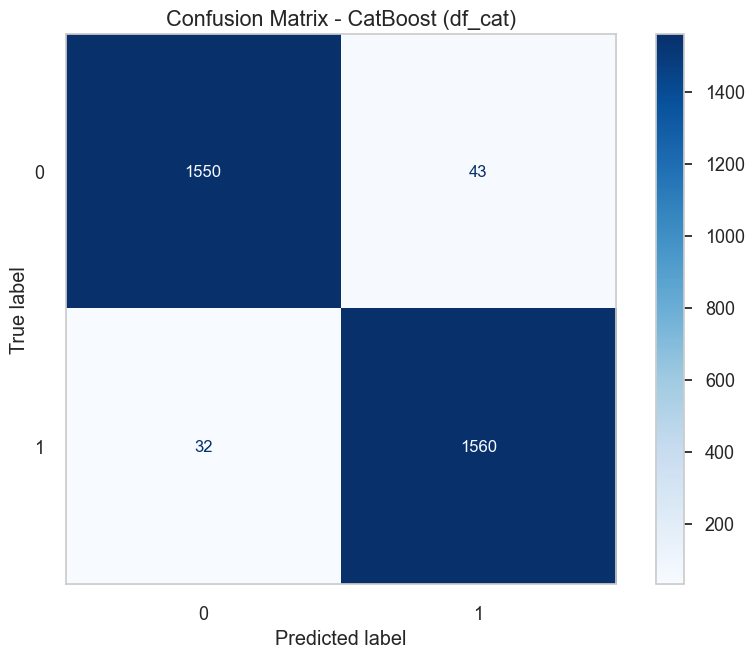

In [242]:
# Karmaşıklık matrisi hesapla
cm = confusion_matrix(y_test, y_pred)

# Görselleştir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cat_model.classes_)
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - CatBoost (df_cat)")
plt.grid(False)
plt.show()

In [243]:
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {auc_score:.4f}")

ROC AUC: 0.9973


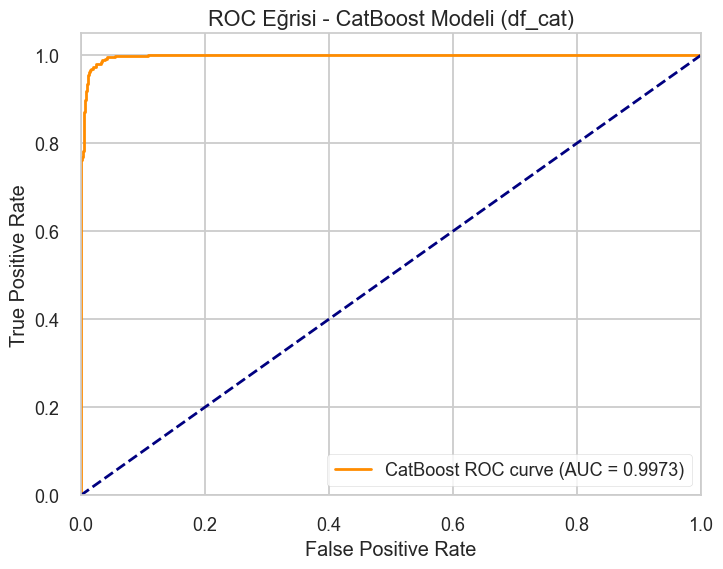

In [244]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC eğrisi için fpr (False Positive Rate) ve tpr (True Positive Rate) hesapla
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'CatBoost ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi - CatBoost Modeli (df_cat)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Parametre optimizasyonu

In [245]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

In [246]:
#Parametre aralığı
param_dist = {
    "iterations": [300, 500, 700, 1000],
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "depth": [4, 5, 6, 7, 8, 9, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128, 254],
    "bagging_temperature": np.linspace(0, 1, 10)
}


In [247]:
#RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=30,  # kombinasyon sayısı
    scoring="roc_auc",
    cv=3,  # 3-fold cross validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [248]:
random_search.fit(X_train, y_train, cat_features=cat_features)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=<catboost.core.CatBoostClassifier object at 0x000001BCFE7E5B90>,
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bagging_temperature': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
                                        'border_count': [32, 64, 128, 254],
                                        'depth': [4, 5, 6, 7, 8, 9, 10],
                                        'iterations': [300, 500, 700, 1000],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ])},
                   random_state=42, scoring='roc_auc', verbose=1)

In [249]:
best_model = random_search.best_estimator_

In [250]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [251]:
#Sonuçlar
accuracy_cat_2 = accuracy_score(y_test, y_pred)
roc_auc_cat_2 = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Best Parameters:", random_search.best_params_)

Accuracy: 0.9765
ROC AUC: 0.9973
Best Parameters: {'learning_rate': 0.07444444444444444, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 8, 'border_count': 254, 'bagging_temperature': 0.3333333333333333}


In [252]:
# Eğitim setinde performans
y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Test setinde performans
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# F1 skor (test seti için)
f1 = f1_score(y_test, y_test_pred)

# Sonuçları tabloya koy
results_df = pd.DataFrame({
    "Model": ["catboost"],
    "Train Score": [train_accuracy],
    "Test Score": [test_accuracy],
    "F1 Score": [f1]
})

print(results_df)

      Model  Train Score  Test Score  F1 Score
0  catboost          1.0    0.987127  0.987247


In [253]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1593
           1       0.98      1.00      0.99      1592

    accuracy                           0.99      3185
   macro avg       0.99      0.99      0.99      3185
weighted avg       0.99      0.99      0.99      3185



#### Genel değerlendirme

# Comparative Analysis of Models

In [254]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [255]:
# --- Gerekli Kütüphaneler ---
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# --- Model Performansını Değerlendirme Fonksiyonu ---
def evaluate_model(model, X, y, model_name, dataset_name, scale_data=False):
    # Eğitim ve test ayrımı
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Gerekirse veri ölçekleme
    if scale_data:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    # Model eğitimi
    model.fit(X_train, y_train)

    # Tahminler
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Skorlar
    train_score = accuracy_score(y_train, y_pred_train)
    test_score = accuracy_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train, y_pred_train)
    test_f1 = f1_score(y_test, y_pred_test)

    # Sonucu döndür
    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Train Score": train_score,
        "Test Score": test_score,
        "Train F1 Score": train_f1,
        "Test F1 Score": test_f1
    }

# --- Modelleri Tanımlama (Default ve Optimize CatBoost Dahil) ---
models_to_evaluate = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (Optimize RBF)": SVC(kernel='rbf', C=10, gamma=0.1, random_state=42, probability=True),
    "KNN (Optimize k=3)": KNeighborsClassifier(n_neighbors=3),
    
    # CatBoost Modelleri
    "CatBoost (Optimized)": CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, random_seed=42, eval_metric='AUC', verbose=0),  # Optimized first
    "CatBoost (Default)": CatBoostClassifier(verbose=0, random_seed=42)  # Default second
}

# --- Veri Setlerini Tanımlama ---
datasets = {
    "Orijinal (data_1)": (data_1.drop("Exited", axis=1), data_1["Exited"]),
    "Oversampled": (balanced_data_real.drop("Exited", axis=1), balanced_data_real["Exited"]),
    "Undersampled": (data_balanced.drop("Exited", axis=1), data_balanced["Exited"])
}

# --- Değerlendirme Döngüsü ---
all_results = []

for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\n{dataset_name} veri seti işleniyor...")
    for model_name, model_instance in models_to_evaluate.items():
        if dataset_name == 'Orijinal (data_1)':
            # Orijinal sette tüm modelleri değerlendir
            scale = model_name in ["Logistic Regression", "SVM (Optimize RBF)", "KNN (Optimize k=3)"]
            result = evaluate_model(model_instance, X_data, y_data, model_name, dataset_name, scale_data=scale)
            all_results.append(result)
        elif model_name in ["Gradient Boosting", "Logistic Regression", "CatBoost (Default)", "CatBoost (Optimized)"]:
            # Diğer veri setlerinde sadece Gradient Boosting, Logistic Regression ve CatBoost'lar değerlendir
            scale = model_name == "Logistic Regression"
            result = evaluate_model(model_instance, X_data, y_data, model_name, dataset_name, scale_data=scale)
            all_results.append(result)

# --- Tüm Sonuçları DataFrame'e Aktarma ---
results_df = pd.DataFrame(all_results)

# --- Sonuçları Görüntüleme ---
print("\nTüm Model Sonuçları:")
print(results_df)



Orijinal (data_1) veri seti işleniyor...

Oversampled veri seti işleniyor...

Undersampled veri seti işleniyor...

Tüm Model Sonuçları:
              Dataset                 Model  Train Score  Test Score  \
0   Orijinal (data_1)     Gradient Boosting     0.948000    0.941500   
1   Orijinal (data_1)   Logistic Regression     0.805125    0.806500   
2   Orijinal (data_1)    SVM (Optimize RBF)     0.974500    0.954500   
3   Orijinal (data_1)    KNN (Optimize k=3)     0.961375    0.928000   
4   Orijinal (data_1)  CatBoost (Optimized)     0.987375    0.968000   
5   Orijinal (data_1)    CatBoost (Default)     0.987250    0.968500   
6         Oversampled     Gradient Boosting     0.932098    0.923077   
7         Oversampled   Logistic Regression     0.689772    0.688540   
8         Oversampled  CatBoost (Optimized)     0.989481    0.976452   
9         Oversampled    CatBoost (Default)     0.992778    0.980220   
10       Undersampled     Gradient Boosting     0.929755    0.916667   

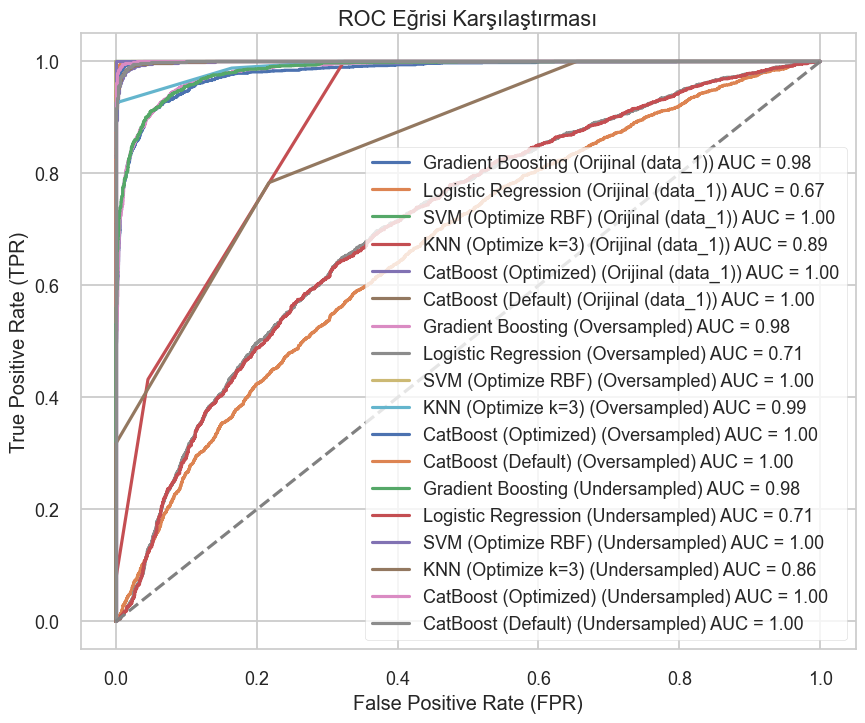

In [256]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- ROC Eğrisini Çizme ve AUC Hesaplama Fonksiyonu ---
def plot_roc_curve(models_to_evaluate, datasets):
    plt.figure(figsize=(10, 8))
    
    for dataset_name, (X_data, y_data) in datasets.items():
        for model_name, model_instance in models_to_evaluate.items():
            # Modeli eğit ve tahmin yap
            model_instance.fit(X_data, y_data)
            y_pred_proba = model_instance.predict_proba(X_data)[:, 1]
            
            # ROC eğrisini ve AUC'yu hesapla
            fpr, tpr, _ = roc_curve(y_data, y_pred_proba)
            auc_score = auc(fpr, tpr)
            
            # ROC eğrisini çiz
            plt.plot(fpr, tpr, label=f'{model_name} ({dataset_name}) AUC = {auc_score:.2f}')
    
    # Eğriyi çiz
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random classifier için referans çizgisi
    plt.title('ROC Eğrisi Karşılaştırması')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.show()

# --- ROC Eğrisini Çizme ve AUC Hesaplama ---
plot_roc_curve(models_to_evaluate, datasets)


# devamı

In [257]:
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)


# --- Değerlendirme Fonksiyonu ---
def evaluate_model(model, X, y, model_name, dataset_name, scale_data=True, random_state=42):
    """Bir modeli eğitir, değerlendirir ve sonuçları döndürür."""
    results = {
        'Model': model_name,
        'Dataset': dataset_name,
        'Test Accuracy': np.nan,
        'Test F1 Score (Exited=1)': np.nan,
        'Test AUC': np.nan
    }
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y if dataset_name=='Orijinal (data_1)' else None) # Orijinalde stratify önemli olabilir

        if scale_data:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # Modeli eğit
        model.fit(X_train, y_train)

        # Tahmin yap
        y_pred = model.predict(X_test)

        # Metrikleri hesapla
        results['Test Accuracy'] = accuracy_score(y_test, y_pred)
        # Classification report'tan F1 skorunu al (label=1 için)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        if '1' in report: # Eğer '1' sınıfı varsa (nadiren olmaz ama kontrol edelim)
             results['Test F1 Score (Exited=1)'] = report['1']['f1-score']
        else:
             results['Test F1 Score (Exited=1)'] = 0.0 # Veya np.nan

        # AUC hesapla (olasılık tahmini yapabiliyorsa)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            results['Test AUC'] = roc_auc_score(y_test, y_proba)
        else:
             # SVM'de probability=False ise predict_proba çalışmaz
             # Karar fonksiyonu varsa ona göre AUC hesaplanabilir ama şimdilik NaN bırakalım
             results['Test AUC'] = np.nan
             
    except Exception as e:
        print(f"Hata ({model_name}, {dataset_name}): {e}")
        # Hata durumunda bile sonuç sözlüğünü döndürelim ki eksik kalmasın
        
    return results


In [258]:
# --- Modelleri Tanımlama (Notebook'taki ayarlarla veya en iyi parametrelerle) ---
models_to_evaluate = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    # SVM için optimizasyon sonrası en iyi parametreleri kullanalım (AUC için probability=True ekleyelim)
    "SVM (Optimize RBF)": SVC(kernel='rbf', C=10, gamma=0.1, random_state=42, probability=True), 
    # KNN için optimizasyon sonrası en iyi k değerini kullanalım
    "KNN (Optimize k=3)": KNeighborsClassifier(n_neighbors=3) 
}

# --- Veri Setlerini ve İsimlerini Tanımlama ---
# Bu DataFrame'lerin notebook ortamında önceden oluşturulduğunu varsayıyoruz
datasets = {
    "Orijinal (data_1)": (data_1.drop("Exited", axis=1), data_1["Exited"]),
    "Oversampled": (balanced_data_real.drop("Exited", axis=1), balanced_data_real["Exited"]),
    "Undersampled": (data_balanced.drop("Exited", axis=1), data_balanced["Exited"])
}

# --- Değerlendirmeleri Çalıştırma ---
all_results = []

for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\n{dataset_name} veri seti işleniyor...")
    for model_name, model_instance in models_to_evaluate.items():
        # SVM ve KNN genellikle orijinal veri seti üzerinde optimize edildi, 
        # diğerleri tüm setlerde denendi. Notebook'taki akışa göre ayarlayalım.
        if dataset_name == 'Orijinal (data_1)':
             # Orijinal sette tüm modelleri değerlendir (SVM ve KNN optimize edilmiş haliyle)
             # LogReg, SVM, KNN için ölçekleme gerekli
             scale = model_name in ["Logistic Regression", "SVM (Optimize RBF)", "KNN (Optimize k=3)"]
             result = evaluate_model(model_instance, X_data, y_data, model_name, dataset_name, scale_data=scale)
             all_results.append(result)
        elif model_name in ["Gradient Boosting", "Logistic Regression"]:
            # GBM ve LogReg diğer setlerde de denendi
            scale = model_name == "Logistic Regression" # GBM ağaç tabanlı, ölçekleme gerekmez
            result = evaluate_model(model_instance, X_data, y_data, model_name, dataset_name, scale_data=scale)
            all_results.append(result)
            


Orijinal (data_1) veri seti işleniyor...

Oversampled veri seti işleniyor...

Undersampled veri seti işleniyor...


In [259]:
# --- Sonuçları DataFrame'e Aktarma ve Gösterme ---
results_df_auto = pd.DataFrame(all_results)
results_df_auto = results_df_auto.sort_values(by=['Dataset', 'Test Accuracy'], ascending=[True, False]).reset_index(drop=True)

print("\n" + "="*50 + "\n")
print("Modellerin Otomatik Olarak Hesaplanmış Karşılaştırmalı Performans Özeti:")
print(results_df_auto)
print("\n" + "="*50 + "\n")



Modellerin Otomatik Olarak Hesaplanmış Karşılaştırmalı Performans Özeti:
                 Model            Dataset  Test Accuracy  \
0   SVM (Optimize RBF)  Orijinal (data_1)       0.954500   
1    Gradient Boosting  Orijinal (data_1)       0.941500   
2   KNN (Optimize k=3)  Orijinal (data_1)       0.928000   
3  Logistic Regression  Orijinal (data_1)       0.806500   
4    Gradient Boosting        Oversampled       0.933438   
5  Logistic Regression        Oversampled       0.703925   
6    Gradient Boosting       Undersampled       0.912990   
7  Logistic Regression       Undersampled       0.683824   

   Test F1 Score (Exited=1)  Test AUC  
0                  0.884664  0.975175  
1                  0.845033  0.982610  
2                  0.813472  0.927962  
3                  0.202062  0.768747  
4                  0.932570  0.985639  
5                  0.699203  0.775268  
6                  0.912454  0.973645  
7                  0.684597  0.751472  





--- Orijinal (data_1) Veri Seti Üzerindeki Karşılaştırma ---


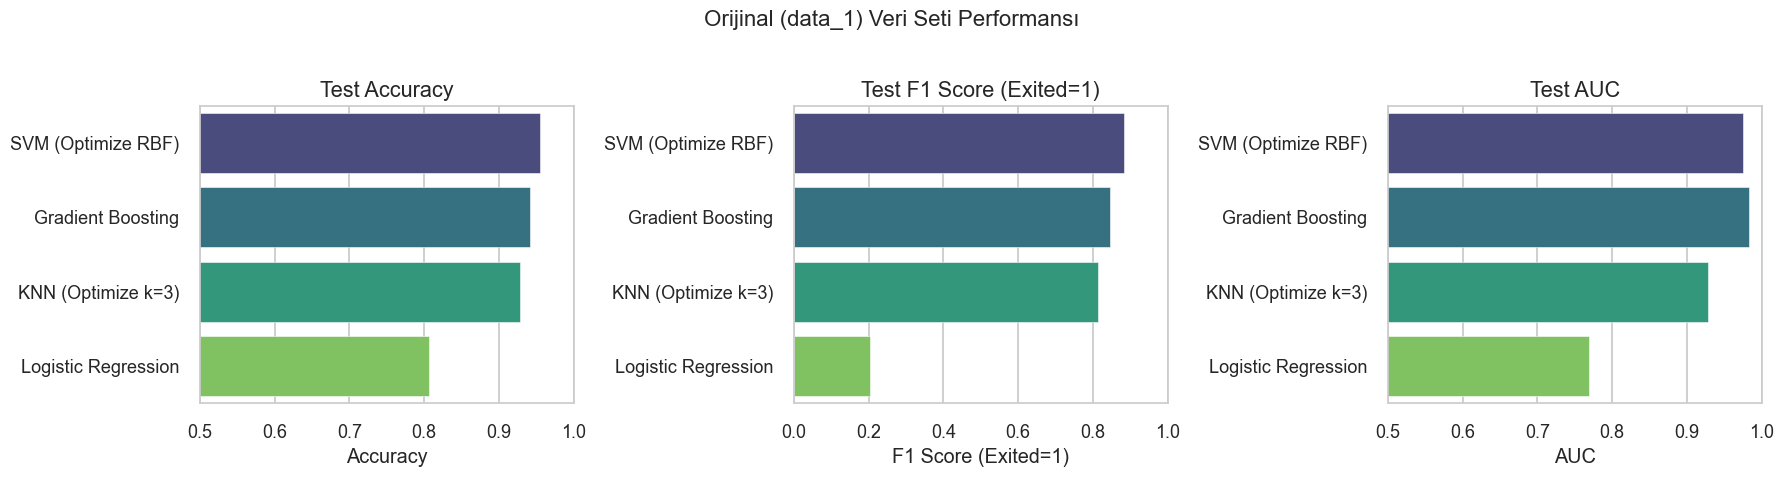




--- Oversampled Veri Seti Üzerindeki Karşılaştırma ---


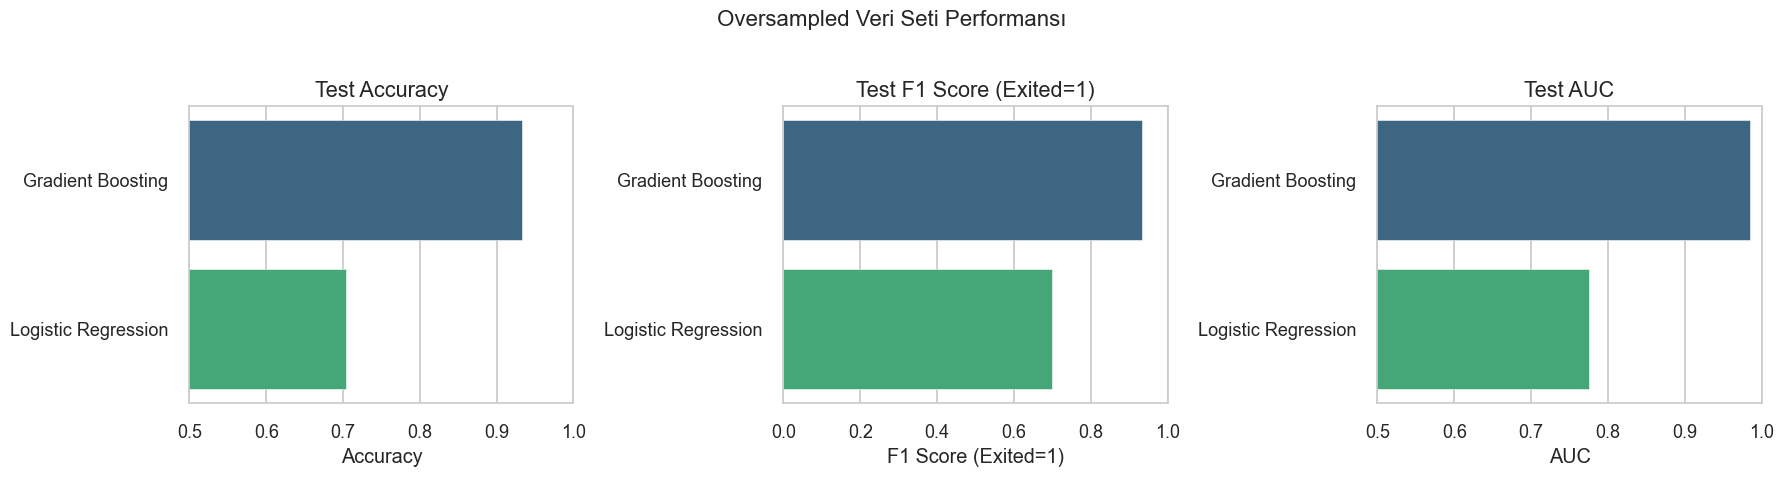




--- Undersampled Veri Seti Üzerindeki Karşılaştırma ---


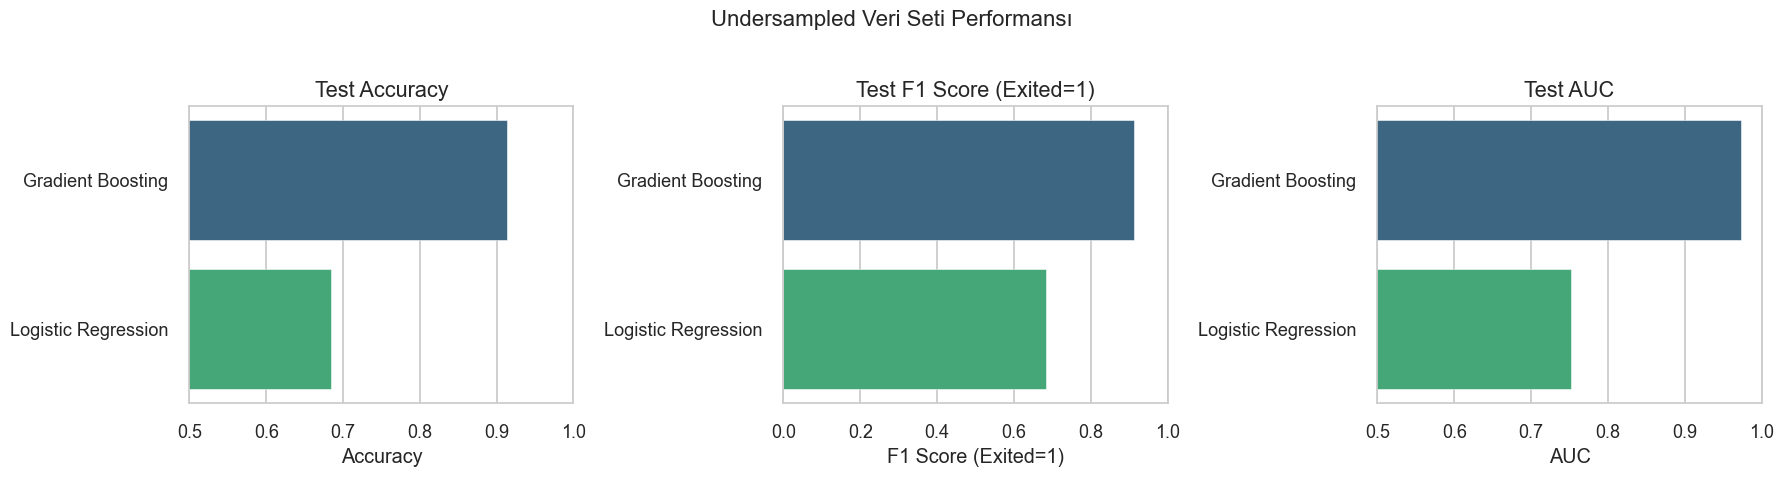

In [260]:
# --- Görselleştirme (Önceki kodla aynı, sadece df adı değişti) ---

datasets_unique = results_df_auto['Dataset'].unique()

for dataset_type in datasets_unique:
    print(f"\n--- {dataset_type} Veri Seti Üzerindeki Karşılaştırma ---")
    df_subset = results_df_auto[results_df_auto['Dataset'] == dataset_type].set_index('Model')
    
    # Sadece bu veri setinde çalışan modelleri al
    models_in_subset = df_subset.index
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    fig.suptitle(f'{dataset_type} Veri Seti Performansı', fontsize=16)

    # Accuracy Plot
    if not df_subset['Test Accuracy'].isnull().all():
        sns.barplot(x=df_subset['Test Accuracy'], y=models_in_subset, ax=axes[0], palette='viridis', orient='h')
        axes[0].set_title('Test Accuracy')
        axes[0].set_xlim(0.5, 1.0)
        axes[0].set_xlabel('Accuracy')
        axes[0].set_ylabel('')
    else:
         axes[0].set_title('Test Accuracy (Veri Yok)')
         axes[0].text(0.5, 0.5, 'Veri Yok', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

    # F1 Score Plot
    if not df_subset['Test F1 Score (Exited=1)'].isnull().all():
        sns.barplot(x=df_subset['Test F1 Score (Exited=1)'], y=models_in_subset, ax=axes[1], palette='viridis', orient='h')
        axes[1].set_title('Test F1 Score (Exited=1)')
        axes[1].set_xlim(0.0, 1.0)
        axes[1].set_xlabel('F1 Score (Exited=1)')
        axes[1].set_ylabel('')
    else:
         axes[1].set_title('Test F1 Score (Exited=1) (Veri Yok)')
         axes[1].text(0.5, 0.5, 'Veri Yok', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

    # AUC Plot
    if not df_subset['Test AUC'].isnull().all():
        df_auc_subset = df_subset.dropna(subset=['Test AUC'])
        if not df_auc_subset.empty:
           sns.barplot(x=df_auc_subset['Test AUC'], y=df_auc_subset.index, ax=axes[2], palette='viridis', orient='h')
           axes[2].set_title('Test AUC')
           axes[2].set_xlim(0.5, 1.0)
           axes[2].set_xlabel('AUC')
           axes[2].set_ylabel('')
        else:
           axes[2].set_title('Test AUC (Veri Yok)')
           axes[2].text(0.5, 0.5, 'Veri Yok', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)

    else:
         axes[2].set_title('Test AUC (Veri Yok)')
         axes[2].text(0.5, 0.5, 'Veri Yok', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    print("\n" + "="*50 + "\n")

# For Stremalit Model

## Oversampled    CatBoost (Default)

In [261]:
df_cat_ = data1.copy()

In [262]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real_cat = df_cat_[df_cat['Exited'] == 1]
minority_class_real_cat = df_cat_[df_cat['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
minority_class_real_cat = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
minority_class_real_cat['Exited'].value_counts(), minority_class_real_cat.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [263]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Özellikler ve hedef değişken
X = minority_class_real_cat.drop("Exited", axis=1)
y = minority_class_real_cat["Exited"]

# 2. Eğitim ve test bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Kategorik sütun indekslerini al
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

# 4. Modeli tanımla ve eğit
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

# 5. Tahmin ve değerlendirme
y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9765


In [264]:
from sklearn.metrics import f1_score, accuracy_score

# Train verisinde tahmin yap
y_train_pred = cat_model.predict(X_train)

# Train ve Test için F1 skorlarını hesapla
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_pred)

# Train ve Test için doğruluk skorlarını da hesaplayalım (Accuracy zaten vardı ama toplu olsun)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train F1 Score: {train_f1:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")


Train Accuracy: 0.9895
Test Accuracy: 0.9765
Train F1 Score: 0.9895
Test F1 Score: 0.9765


In [265]:
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9798    0.9730    0.9764      1593
           1     0.9732    0.9799    0.9765      1592

    accuracy                         0.9765      3185
   macro avg     0.9765    0.9765    0.9765      3185
weighted avg     0.9765    0.9765    0.9765      3185



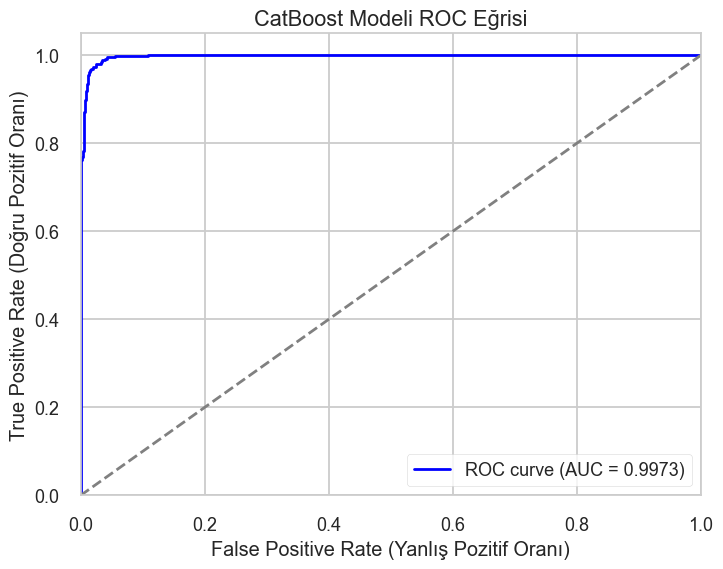

In [266]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Test seti üzerinde olasılık tahminleri al (pozitif sınıf için)
y_proba = cat_model.predict_proba(X_test)[:, 1]

# 2. ROC Curve için FPR ve TPR hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 3. AUC hesapla
roc_auc = auc(fpr, tpr)

# 4. ROC grafiğini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")  # Random model çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (Yanlış Pozitif Oranı)")
plt.ylabel("True Positive Rate (Doğru Pozitif Oranı)")
plt.title("CatBoost Modeli ROC Eğrisi")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
